## Kepler's Third Law of Planetary

In [1]:
from d2l import torch as d2l
import torch
import numpy as np
import matplotlib.pyplot as plt

### 1. Training

#### 1.1 Preprogress of data

In [2]:
d = torch.tensor([0.387, 0.723, 1.000, 1.523, 5.203, 9.541, 19.190, 30.086]).reshape(-1, 1)
T = torch.tensor([0.241, 0.615, 1.000, 1.881, 11.861, 29.457, 84.008, 164.784]).reshape(-1, 1)

X = torch.log(d)
y = torch.log(T)

#### 1.2 Analytic Solution &ensp;<font size=2>*Normal Equation*

In [3]:
# 在X末尾添加一列1，以最终解得联合参数(w, b)
X_expend = torch.cat((X, torch.ones(X.shape[0], 1)), dim=1)
w, b = np.linalg.solve(X_expend.T @ X_expend, X_expend.T @ y)
w, b

(array([1.4995288], dtype=float32), array([0.00043123], dtype=float32))

$$log(T) = wlog(d) + b $$     
$$ T = e^bd^w $$

#### 1.3 Minibatch Stochastic Gradient Descent

In [4]:
class PlanetaryMotionRegressionData(d2l.DataModule):
    """Planet's data to fit Kepler's Third Law of PLanetary Motion."""
    def __init__(self, d, T, batch_size=4, num_train=6):       
        super().__init__()
        self.save_hyperparameters()
        self.X = torch.log(d)
        self.y = torch.log(T)

    def get_tensorloader(self, tensors, train, indices=slice(0, None)):
        tensors = tuple(a[indices] for a in tensors)
        dataset = torch.utils.data.TensorDataset(*tensors)
        return torch.utils.data.DataLoader(dataset, self.batch_size, shuffle=train)

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader((self.X, self.y), train, i)

In [5]:
data = PlanetaryMotionRegressionData(d, T)

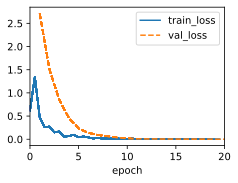

In [6]:
model = d2l.LinearRegression(lr=0.05)  
trainer = d2l.Trainer(max_epochs=20)
trainer.fit(model, data)

In [7]:
weight, bias = model.get_w_b()
weight, bias

(tensor([[1.4854]]), tensor([0.0217]))

Similarly,    
$$log(T) = weight \times log(d) + bias$$    
$$T = e^{bias} \times d^{weight}$$

#### 1.4 Visualization

In [8]:
x_vals = np.linspace(data.X[0].item(), data.X[-1].item(), 100)
# Normal Equation
y_NE = (w * x_vals).reshape(x_vals.shape)
# Minibatch SGD
y_SGD = (weight.numpy() * x_vals + bias.numpy()).reshape(x_vals.shape)

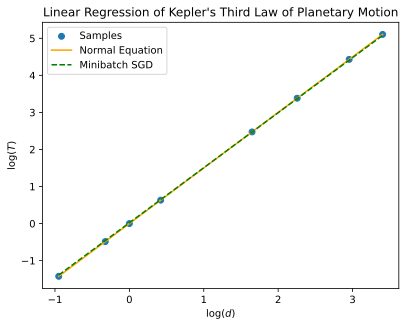

In [9]:
plt.scatter(data.X.numpy(), data.y.numpy(), label='Samples')
plt.plot(x_vals, y_NE, label='Normal Equation', color='orange')
plt.plot(x_vals, y_SGD, label='Minibatch SGD', color='green', linestyle='--')
plt.xlabel('log($d$)')
plt.ylabel('log($T$)')
plt.title("Linear Regression of Kepler's Third Law of Planetary Motion")
plt.legend()
plt.show()

### 2. Testing &ensp;<font size=2>*On Minibatch SGD*

#### 2.1 Predict by forward methord

In [10]:
input_test = torch.tensor([2.77, 39.5]).reshape(-1, 1)
output_test = model.forward(input_test)
input_test, output_test

(tensor([[ 2.7700],
         [39.5000]]),
 tensor([[ 4.1361],
         [58.6932]], grad_fn=<AddmmBackward0>))

#### 2.2 Visualization

In [11]:
x_total = torch.cat((data.X, input_test), dim=0).detach().numpy()
y_total = torch.cat((data.y, output_test), dim=0).detach().numpy()

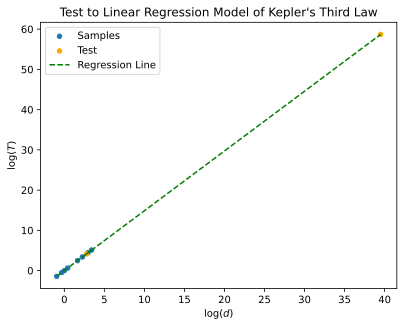

In [12]:
input_test, output_test = input_test.detach().numpy(), output_test.detach().numpy()
plt.scatter(data.X.numpy(), data.y.numpy(), label='Samples', s=20)
plt.scatter(input_test, output_test, label='Test', color='orange', s=20)
plt.plot(x_total, y_total, label="Regression Line", color='green', linestyle='--')
plt.xlabel('log($d$)')
plt.ylabel('log($T$)')
plt.title("Test to Linear Regression Model of Kepler's Third Law")
plt.legend()
plt.show()

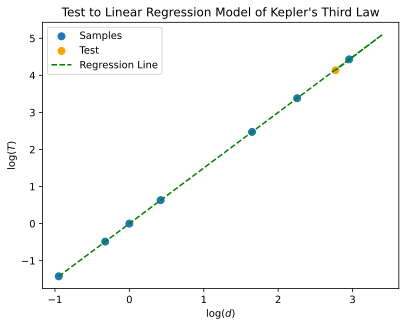

In [13]:
# To better show the position of Ceres, ignore Pluto (sorry about that) temporarily.
plt.scatter(data.X.numpy()[0: -1], data.y.numpy()[0: -1], label='Samples', s=50)
plt.scatter(input_test[0: -1], output_test[0: -1], label='Test', color='orange', s=50)
plt.plot(x_total[0: -1], y_total[0: -1], label="Regression Line", color='green', linestyle='--')
plt.xlabel('log($d$)')
plt.ylabel('log($T$)')
plt.title("Test to Linear Regression Model of Kepler's Third Law")
plt.legend()
plt.show()